In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("student_performance_linear_regression.csv")

In [3]:
df.shape

(250, 5)

In [4]:
df.head()

,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Exam_Score
0,1.5,60,89,6.6,38.3
1,9.1,57,64,7.1,35.0
2,8.7,65,48,6.3,35.0
3,3.2,55,67,8.1,39.1
4,4.4,55,60,7.9,35.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Study_Hours     250 non-null    float64
 1   Attendance      250 non-null    int64  
 2   Previous_Score  250 non-null    int64  
 3   Sleep_Hours     250 non-null    float64
 4   Exam_Score      250 non-null    float64
dtypes: float64(3), int64(2)
memory usage: 9.9 KB


In [6]:
df.describe()

,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Exam_Score
count,250.000000,250.000000,250.000000,250.000000,250.000000
mean,5.288400,78.780000,65.352000,7.050000,40.128800
std,2.709359,13.372768,16.083745,1.124436,5.899136
min,1.000000,55.000000,40.000000,5.000000,35.000000
25%,2.825000,67.000000,51.000000,6.200000,35.000000
50%,5.200000,80.000000,64.000000,6.950000,37.650000
75%,7.675000,92.000000,80.000000,8.000000,43.725000
max,9.900000,100.000000,95.000000,9.000000,56.300000


In [7]:
df.isnull().sum()

Study_Hours       0
Attendance        0
Previous_Score    0
Sleep_Hours       0
Exam_Score        0
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Study_Hours,250.0,5.2884,2.709359,1.0,2.825,5.20,7.675,9.9
Attendance,250.0,78.7800,13.372768,55.0,67.000,80.00,92.000,100.0
Previous_Score,250.0,65.3520,16.083745,40.0,51.000,64.00,80.000,95.0
Sleep_Hours,250.0,7.0500,1.124436,5.0,6.200,6.95,8.000,9.0
Exam_Score,250.0,40.1288,5.899136,35.0,35.000,37.65,43.725,56.3


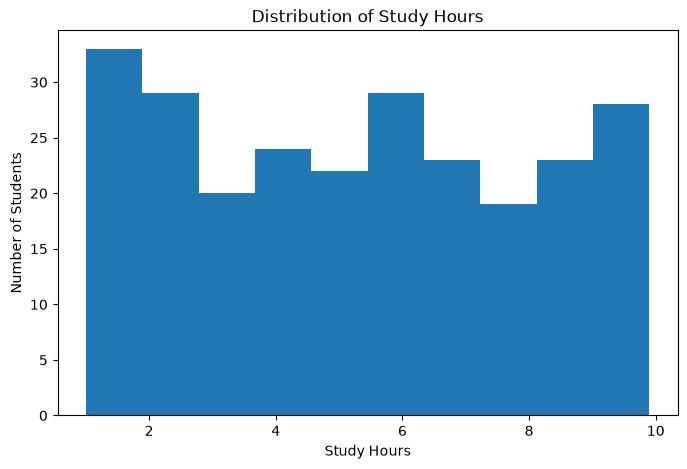

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(df["Study_Hours"], bins=10)

plt.xlabel("Study Hours")
plt.ylabel("Number of Students")
plt.title("Distribution of Study Hours")

plt.show()

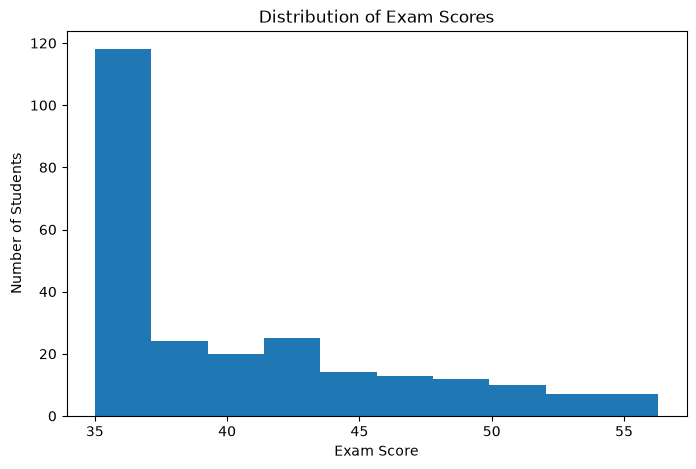

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df["Exam_Score"], bins=10)

plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Exam Scores")

plt.show()

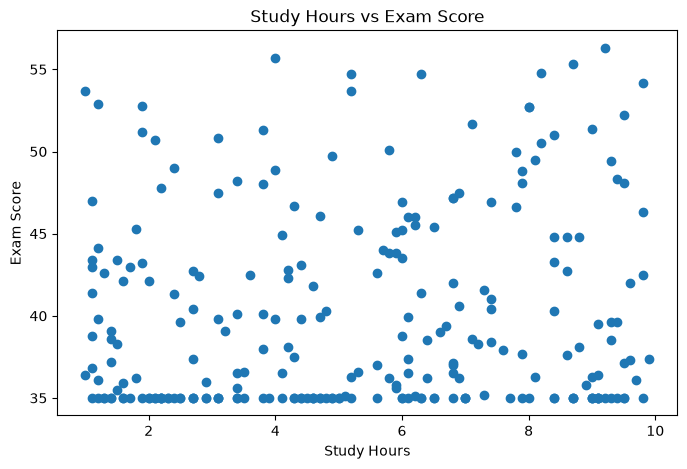

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Study_Hours"], df["Exam_Score"])

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")

plt.show()

In [12]:
df["Study_Hours"].corr(df["Exam_Score"])

np.float64(0.10810852680319291)

In [13]:
df.corr(numeric_only=True)

,Study_Hours,Attendance,Previous_Score,Sleep_Hours,Exam_Score
Study_Hours,1.000000,0.001448,0.045456,-0.001298,0.108109
Attendance,0.001448,1.000000,0.066199,-0.046860,0.393828
Previous_Score,0.045456,0.066199,1.000000,-0.160242,0.800873
Sleep_Hours,-0.001298,-0.046860,-0.160242,1.000000,-0.029328
Exam_Score,0.108109,0.393828,0.800873,-0.029328,1.000000


In [15]:
x = df[["Previous_Score"]]
y = df["Exam_Score"]

In [17]:
print(x.head())
print(y.head())

   Previous_Score
0              89
1              64
2              48
3              67
4              60
0    38.3
1    35.0
2    35.0
3    39.1
4    35.0
Name: Exam_Score, dtype: float64


In [18]:
print(x.shape)
print(y.shape)

(250, 1)
(250,)


In [19]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.29]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Previous_Score']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,21.33
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [23]:
print("Slope", model.coef_[0])
print("Intercept:", model.intercept_)

Slope 0.28716431460362274
Intercept: 21.331743537728364


In [24]:
y_pred = model.predict(x_test)
print(y_pred[:10])

[42.00757419 43.15623145 45.16638165 37.98727378 40.57175262 35.68995927
 45.74071028 47.17653185 42.00757419 48.0380248 ]


In [25]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual  Predicted
0    42.8  42.007574
1    42.5  43.156231
2    42.6  45.166382
3    35.0  37.987274
4    35.0  40.571753
5    35.0  35.689959
6    51.2  45.740710
7    47.5  47.176532
8    43.4  42.007574
9    52.8  48.038025


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

MAE  : 2.8524520447187034
MSE  : 12.659199814007401
RMSE : 3.5579769271325246
R²   : 0.6607428204246106


In [29]:
new_student = pd.DataFrame({
    "Previous_Score": [75]
})

predicted_score = model.predict(new_student)

print("Predicted Exam Score:", predicted_score[0])

Predicted Exam Score: 42.86906713300007


In [30]:
new_students = pd.DataFrame({
    "Previous_Score": [50, 60, 70, 80, 90]
})

predictions = model.predict(new_students)

result = pd.DataFrame({
    "Previous_Score": new_students["Previous_Score"],
    "Predicted_Exam_Score": predictions
})

print(result)

   Previous_Score  Predicted_Exam_Score
0              50             35.689959
1              60             38.561602
2              70             41.433246
3              80             44.304889
4              90             47.176532
